## 2026 NFL Fantasy Rankings Project Part 4 - Combined Rankings

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
%matplotlib inline

C:\Users\kevin\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\kevin\anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\kevin\anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
final_rb = pd.read_csv('../outputs/ensemble_rbs_2026_prediction.csv')

In [3]:
final_wr = pd.read_csv('../outputs/ensemble_wrs_2026_prediction.csv')

The two code blocks below are from the outputs of my 2026 rookie projection project: https://github.com/kevinkietle/2026-Fantasy-Football-Rookie-Rankings

In [4]:
rookie_rb = pd.read_csv('../inputs/ensemble_rookie_rbs_2026_prediction.csv')

In [12]:
rookie_wr = pd.read_csv('../inputs/ensemble_rookie_wrs_2026_prediction.csv')

In [13]:
final_rb["Position"] = "RB"
final_wr["Position"] = "WR"
rookie_rb["Position"] = "RB"
rookie_wr["Position"] = "WR"

In [15]:
cols_to_keep = [
    "Name",
    "Mean",
    "5th Percentile",
    "95th Percentile",
    "Position"
]

for df in [final_rb, final_wr, rookie_rb, rookie_wr]:
    df.drop(columns=df.columns.difference(cols_to_keep), inplace=True)

In [16]:
final_rb.head()

,Name,Mean,5th Percentile,95th Percentile,Position
0,Christian McCaffrey,18.118900,15.935197,20.266904,RB
1,Bijan Robinson,17.578895,15.146389,19.820875,RB
2,Jahmyr Gibbs,16.743155,14.919171,18.512878,RB
3,Jonathan Taylor,15.730945,13.784408,17.776977,RB
4,De'Von Achane,15.576741,13.621471,17.640496,RB


In [17]:
final_wr.head()

,Name,Mean,5th Percentile,95th Percentile,Position
0,Puka Nacua,20.063570,18.086727,21.924352,WR
1,Ja'Marr Chase,18.686045,17.056037,20.296347,WR
2,Amon-Ra St. Brown,17.689166,16.117847,19.266984,WR
3,Jaxon Smith-Njigba,16.987141,15.215388,18.775255,WR
4,George Pickens,16.349182,14.935557,17.780523,WR


In [18]:
rookie_rb.head()

,Name,Mean,5th Percentile,95th Percentile,Position
0,Jeremiyah Love,10.971981,8.985860,12.947175,RB
1,Jadarian Price,10.117914,8.240355,11.954041,RB
2,Kaelon Black,4.997404,3.693783,6.537000,RB
3,Jonah Coleman,4.734259,3.533922,6.198466,RB
4,Mike Washington,4.586828,3.334446,6.139031,RB


In [19]:
rookie_wr.head()

,Name,Mean,5th Percentile,95th Percentile,Position
0,Carnell Tate,12.688588,2.076614,26.781431,WR
1,De'Zhaun Stribling,10.382731,8.717513,11.942729,WR
2,KC Concepcion,10.190227,8.208912,12.138168,WR
3,Caleb Douglas,9.505261,0.801718,20.218020,WR
4,Jordyn Tyson,9.344448,7.631684,11.134568,WR


In [20]:
combined_df = pd.concat(
    [final_rb, final_wr, rookie_rb, rookie_wr],
    ignore_index=True
).sort_values(
    "Mean",
    ascending=False
).reset_index(drop=True)

In [21]:
combined_df

,Name,Mean,5th Percentile,95th Percentile,Position
0,Puka Nacua,20.063570,18.086727,21.924352,WR
1,Ja'Marr Chase,18.686045,17.056037,20.296347,WR
2,Christian McCaffrey,18.118900,15.935197,20.266904,RB
3,Amon-Ra St. Brown,17.689166,16.117847,19.266984,WR
4,Bijan Robinson,17.578895,15.146389,19.820875,RB
...,...,...,...,...,...
150,Deion Burks,2.355726,0.637703,3.981839,WR
151,Josh Cameron,2.322638,-4.525626,7.240552,WR
152,Eli Heidenreich,2.052567,0.477411,3.590644,WR
153,Emmanuel Henderson,1.545783,-0.581521,3.823637,WR


In [22]:
combined_df.to_csv('../outputs/combined_2026_rankings.csv', index=False)

In [24]:
# Get top 24 players by Mean
top_24 = (
    combined_df
    .sort_values("Mean", ascending=False)
    .head(24)
    .copy()
)

# Reverse so highest-ranked player appears at the top
top_24 = top_24.sort_values("Mean", ascending=True)

# Create colors based on position
colors = top_24["Position"].map({
    "WR": "blue",
    "RB": "green"
})

labels = [
    f"{rank}. {name} ({position})"
    for rank, (name, position) in zip(
        range(24, 0, -1),
        zip(top_24["Name"], top_24["Position"])
    )
]

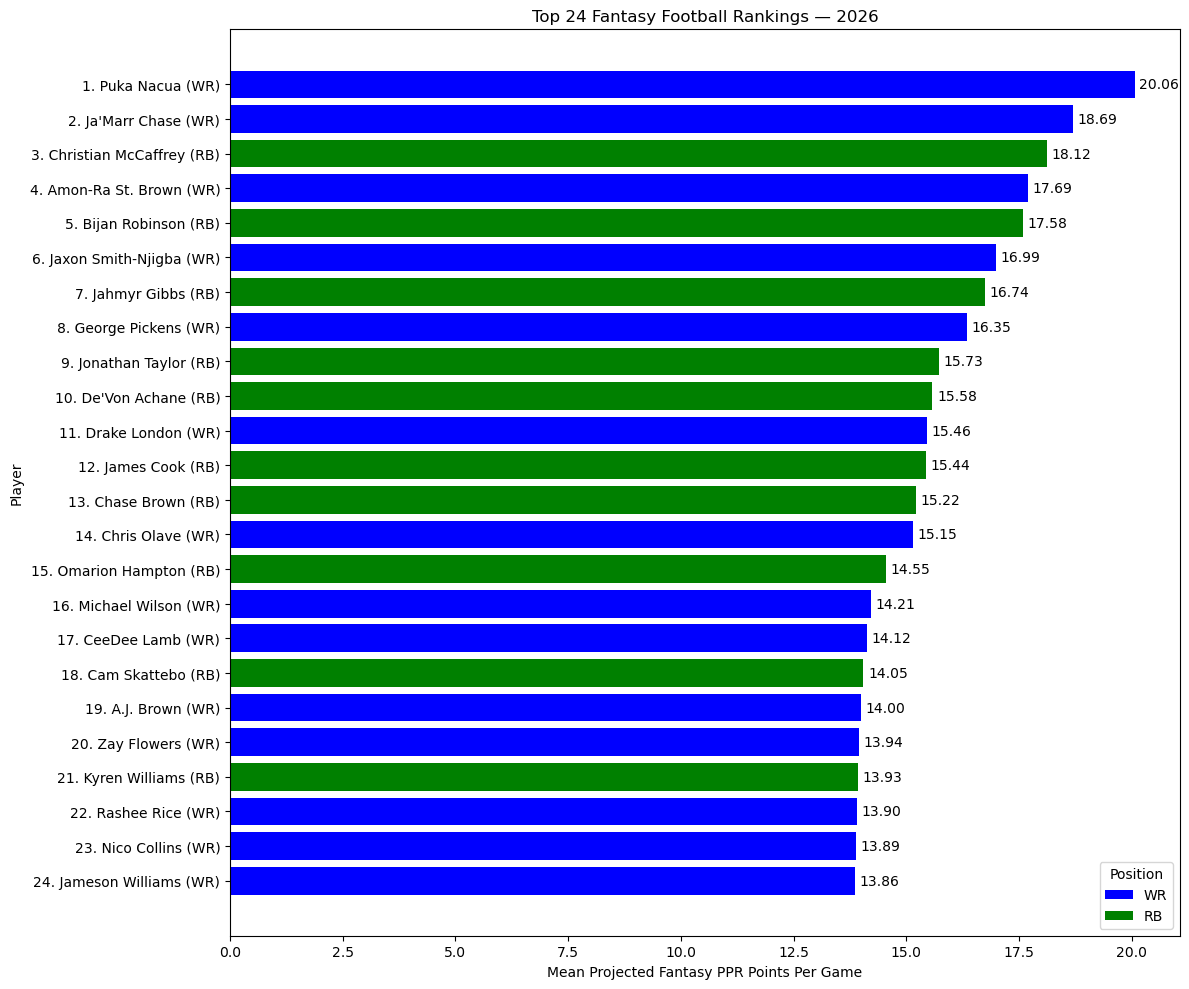

In [26]:
# Plot
plt.figure(figsize=(12, 10))

plt.barh(
    labels,
    top_24["Mean"],
    color=colors
)

# Add Mean values next to bars
for i, value in enumerate(top_24["Mean"]):
    plt.text(
        value + 0.1,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.xlabel("Mean Projected Fantasy PPR Points Per Game")
plt.ylabel("Player")
plt.title("Top 24 Fantasy Football Rankings — 2026")

# Legend
legend_elements = [
    Patch(facecolor="blue", label="WR"),
    Patch(facecolor="green", label="RB")
]

plt.legend(handles=legend_elements, title="Position")

plt.tight_layout()

# Save image
plt.savefig(
    "../images/combined_2026_rankings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()